In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

Mounted at /content/drive


## Tile 3 IA

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


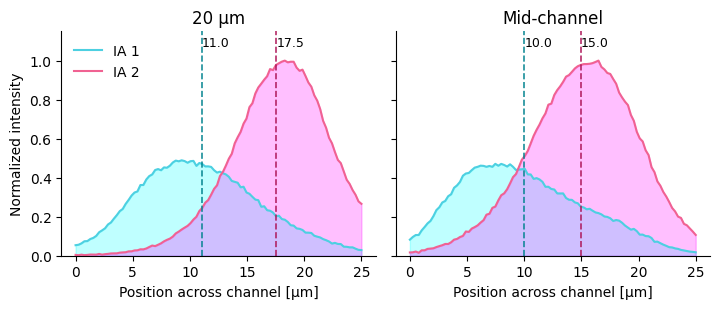

In [6]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

data_dir = Path('/content/drive/MyDrive/Colab Notebooks/MEP/diffusion_data')

ia1 = pd.read_csv(data_dir / 'tilescan3_IA_IA_1.csv')
ia2 = pd.read_csv(data_dir / 'tilescan3_IA_IA_2.csv')

# --- BACKGROUND VALUES from empty-region ROIs in Fiji ---
bg_ia1 = 104.272
bg_ia2 = 104.352

distance = ia1['Distance_(microns)'].values

# Fiji's Multi Plot column names: first ROI = 'Value', then 'Y1', 'Y2', ...
roi_columns = ['Value', 'Y1']

ia1_profiles = [np.clip(ia1[col].values - bg_ia1, 0, None) for col in roi_columns]
ia2_profiles = [np.clip(ia2[col].values - bg_ia2, 0, None) for col in roi_columns]

panel_titles = ['20 µm', 'Mid-channel']

# Softened cyan and magenta — vivid enough to read as the fluorescence channels,
# but easier on white than pure #00FFFF / #FF00FF
cyan_fill = '#00FFFF'
cyan_line = '#4DD0E1'
magenta_fill = '#FF00FF'
magenta_line = '#F06292'

fig, axes = plt.subplots(1, 2, figsize=(7.3, 3.2), sharey=True)

for ax, c, m, title in zip(axes, ia1_profiles, ia2_profiles, panel_titles):
    norm = max(c.max(), m.max())
    c_n, m_n = c / norm, m / norm

    # Profile curves (only these carry legend labels — avoids duplicates)
    ax.fill_between(distance, c_n, alpha=0.25, color=cyan_fill)
    ax.fill_between(distance, m_n, alpha=0.25, color=magenta_fill)
    ax.plot(distance, c_n, color=cyan_line, linewidth=1.5, label='IA 1')
    ax.plot(distance, m_n, color=magenta_line, linewidth=1.5, label='IA 2')

    # Intensity-weighted centroids — use fill color so they visually
    # belong to their stream
    centroid_c = np.sum(distance * c) / np.sum(c)
    centroid_m = np.sum(distance * m) / np.sum(m)
    ax.axvline(centroid_c, color='#00838F', linestyle='--', linewidth=1.2, alpha=0.9)
    ax.axvline(centroid_m, color='#AD1457', linestyle='--', linewidth=1.2, alpha=0.9)

    # Numerical labels above each centroid line
    ax.text(centroid_c, 1.06, f'{centroid_c:.1f}',
            ha='left', va='bottom', fontsize=9)
    ax.text(centroid_m, 1.06, f'{centroid_m:.1f}',
            ha='left', va='bottom', fontsize=9)

    ax.set_title(title)
    ax.set_xlabel('Position across channel [µm]')
    ax.set_ylim(0, 1.15)   # a bit more headroom for the value labels
    ax.spines[['top', 'right']].set_visible(False)

axes[0].set_ylabel('Normalized intensity')
axes[0].legend(loc='upper left', frameon=False)
plt.tight_layout()
# plt.savefig(data_dir / 'mixing_profiles.png', dpi=300, bbox_inches='tight')
# plt.savefig(data_dir / 'mixing_profiles.pdf', bbox_inches='tight')
plt.show()

## Tile 3 junction

In [2]:
data_dir = Path('/content/drive/MyDrive/Colab Notebooks/MEP/diffusion_data')

ia1 = pd.read_csv(data_dir / 'tilescan3_IA_1.csv')
ia2 = pd.read_csv(data_dir / 'tilescan3_IA_2.csv')

print("IA1 columns:", ia1.columns.tolist())
print(ia1.head())

IA1 columns: ['Distance_(microns)', 'Value', 'Y1', 'Y2']
   Distance_(microns)    Value       Y1       Y2
0              0.0000  109.231  117.282  128.179
1              0.2577  112.872  119.205  128.179
2              0.5154  115.795  119.744  137.744
3              0.7730  117.462  126.410  140.718
4              1.0307  121.205  130.410  143.590


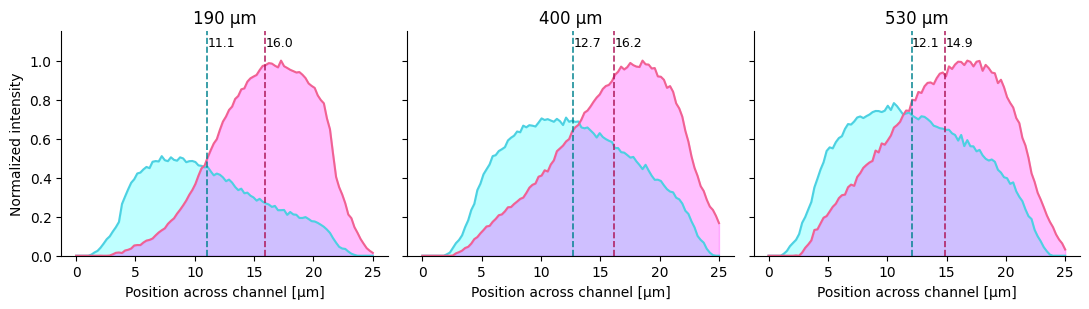

In [5]:
def background_subtract(y, method='percentile'):
    """Subtract a flat background. 'percentile' uses the 10th percentile
    of the profile itself, which works well when the profile has clear
    low-signal regions outside the streams."""
    if method == 'percentile':
        bg = np.percentile(y, 10)
    return np.clip(y - bg, 0, None)

# Pull distance and profile columns. Assumes first column is distance,
# rest are ROIs in the order: junction, mid, downstream.
distance = ia1.iloc[:, 0].values
ia1_profiles = [background_subtract(ia1.iloc[:, i].values) for i in range(1, 4)]
ia2_profiles = [background_subtract(ia2.iloc[:, i].values) for i in range(1, 4)]

# Softened cyan and magenta — vivid enough to read as the fluorescence channels,
# but easier on white than pure #00FFFF / #FF00FF
cyan_fill = '#00FFFF'
cyan_line = '#4DD0E1'
magenta_fill = '#FF00FF'
magenta_line = '#F06292'

# Normalize each profile by the *combined* max at its ROI, so you can see
# how the relative balance shifts as the streams mix. Using a per-channel
# max would hide the fact that one channel can dominate locally.
panel_titles = ['190 µm', '400 µm', '530 µm']

fig, axes = plt.subplots(1, 3, figsize=(11, 3.2), sharey=True)

for ax, c, m, title in zip(axes, ia1_profiles, ia2_profiles, panel_titles):
    norm = max(c.max(), m.max())
    c_n, m_n = c / norm, m / norm

    # Profile curves (only these carry legend labels — avoids duplicates)
    ax.fill_between(distance, c_n, alpha=0.25, color=cyan_fill)
    ax.fill_between(distance, m_n, alpha=0.25, color=magenta_fill)
    ax.plot(distance, c_n, color=cyan_line, linewidth=1.5, label='IA 1')
    ax.plot(distance, m_n, color=magenta_line, linewidth=1.5, label='IA 2')

    # Intensity-weighted centroids — use fill color so they visually
    # belong to their stream
    centroid_c = np.sum(distance * c) / np.sum(c)
    centroid_m = np.sum(distance * m) / np.sum(m)
    ax.axvline(centroid_c, color='#00838F', linestyle='--', linewidth=1.2, alpha=0.9)
    ax.axvline(centroid_m, color='#AD1457', linestyle='--', linewidth=1.2, alpha=0.9)

    # Numerical labels above each centroid line
    ax.text(centroid_c, 1.06, f'{centroid_c:.1f}',
            ha='left', va='bottom', fontsize=9)
    ax.text(centroid_m, 1.06, f'{centroid_m:.1f}',
            ha='left', va='bottom', fontsize=9)

    ax.set_title(title)
    ax.set_xlabel('Position across channel [µm]')
    ax.set_ylim(0, 1.15)   # a bit more headroom for the value labels
    ax.spines[['top', 'right']].set_visible(False)

axes[0].set_ylabel('Normalized intensity')
#axes[-1].legend(loc='upper left', frameon=False)
plt.tight_layout()
# plt.savefig(data_dir / 'mixing_profiles.png', dpi=300, bbox_inches='tight')
# plt.savefig(data_dir / 'mixing_profiles.pdf', bbox_inches='tight')
plt.show()

## Tile 3 GUV

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


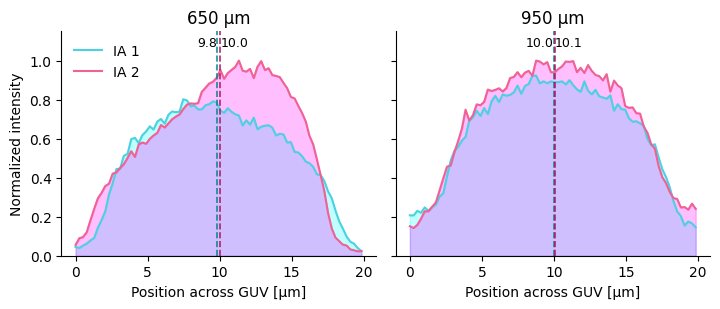

In [8]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

data_dir = Path('/content/drive/MyDrive/Colab Notebooks/MEP/diffusion_data')

ia1 = pd.read_csv(data_dir / 'tilescan3_GUV_IA_1.csv')
ia2 = pd.read_csv(data_dir / 'tilescan3_GUV_IA_2.csv')

# --- BACKGROUND VALUES — replace with what you measured in Fiji ---
bg_ia1 = 104.225   # mean of empty-region ROI on IA1 channel
bg_ia2 = 103.869   # mean of empty-region ROI on IA2 channel

# Distance is the same for both files (same ROIs, same image)
distance = ia1['Distance_(microns)'].values

# Fiji's Multi Plot column names: first ROI = 'Value', then 'Y1', 'Y2', ...
roi_columns = ['Value', 'Y1']

ia1_profiles = [np.clip(ia1[col].values - bg_ia1, 0, None) for col in roi_columns]
ia2_profiles = [np.clip(ia2[col].values - bg_ia2, 0, None) for col in roi_columns]

panel_titles = ['650 µm', '950 µm']

# Softened cyan and magenta — vivid enough to read as the fluorescence channels,
# but easier on white than pure #00FFFF / #FF00FF
cyan_fill = '#00FFFF'
cyan_line = '#4DD0E1'
magenta_fill = '#FF00FF'
magenta_line = '#F06292'

fig, axes = plt.subplots(1, 2, figsize=(7.3, 3.2), sharey=True)

for ax, c, m, title in zip(axes, ia1_profiles, ia2_profiles, panel_titles):
    norm = max(c.max(), m.max())
    c_n, m_n = c / norm, m / norm

    # Profile curves (only these carry legend labels — avoids duplicates)
    ax.fill_between(distance, c_n, alpha=0.25, color=cyan_fill)
    ax.fill_between(distance, m_n, alpha=0.25, color=magenta_fill)
    ax.plot(distance, c_n, color=cyan_line, linewidth=1.5, label='IA 1')
    ax.plot(distance, m_n, color=magenta_line, linewidth=1.5, label='IA 2')

    # Intensity-weighted centroids — use fill color so they visually
    # belong to their stream
    centroid_c = np.sum(distance * c) / np.sum(c)
    centroid_m = np.sum(distance * m) / np.sum(m)
    ax.axvline(centroid_c, color='#00838F', linestyle='--', linewidth=1.2, alpha=0.9)
    ax.axvline(centroid_m, color='#AD1457', linestyle='--', linewidth=1.2, alpha=0.9)

    # Numerical labels above each centroid line
    ax.text(centroid_c, 1.06, f'{centroid_c:.1f}',
            ha='right', va='bottom', fontsize=9)
    ax.text(centroid_m, 1.06, f'{centroid_m:.1f}',
            ha='left', va='bottom', fontsize=9)

    ax.set_title(title)
    ax.set_xlabel('Position across GUV [µm]')
    ax.set_ylim(0, 1.15)   # a bit more headroom for the value labels
    ax.spines[['top', 'right']].set_visible(False)

axes[0].set_ylabel('Normalized intensity')
axes[0].legend(loc='upper left', frameon=False)
plt.tight_layout()
# plt.savefig(data_dir / 'mixing_profiles.png', dpi=300, bbox_inches='tight')
# plt.savefig(data_dir / 'mixing_profiles.pdf', bbox_inches='tight')
plt.show()